<h1>Импорт библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [27]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    n = X[0].shape[0]
    result = np.zeros((n, 1))
    
    for i in range(len(X)):
        result += np.dot(X[i], V[i])
    
    return result
def tests():
    X1 = [np.array([[10, 20], [30, 40]])]
    V1 = [np.array([[5], [10]])]
    result1 = sum_prod(X1, V1)
    print(np.allclose(result1, np.array([[250], [550]])))

    X2 = [np.array([[1, 0], [0, 1]]), np.array([[2, 0], [0, 2]])]
    V2 = [np.array([[1], [1]]), np.array([[1], [1]])]
    result2 = sum_prod(X2, V2)
    print(np.allclose(result2, np.array([[3], [3]])))
tests()


True
True


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [32]:
def binarize(M, threshold=0.5):
    return (M > threshold).astype(int)
def tests():
    result1 = binarize(np.array([[0.1, 0.6, 0.4], [0.9, 0.2, 0.7]]))
    expected1 = np.array([[0, 1, 0], [1, 0, 1]])
    print(np.array_equal(result1, expected1))
    
    result2 = binarize(np.array([[5, 6, 7], [3, 4, 8]]), 5)
    expected4 = np.array([[0, 1, 1], [0, 0, 1]])
    print(np.array_equal(result2, expected4))
tests()

True
True


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [36]:
def unique_rows(mat):
    return [np.unique(row) for row in mat]

def unique_columns(mat):
    return [np.unique(col) for col in mat.T]

def tests():
    mat1 = np.array([[1, 2, 3],
                     [1, 1, 2],
                     [3, 3, 3]])

    result_rows1 = unique_rows(mat1)
    expected_rows1 = [np.array([1, 2, 3]), np.array([1, 2]), np.array([3])]
    for i, (res, exp) in enumerate(zip(result_rows1, expected_rows1)):
        print(np.array_equal(res, exp))
    
    result_cols1 = unique_columns(mat1)
    expected_cols1 = [np.array([1, 3]), np.array([1, 2, 3]), np.array([2, 3])]
    for i, (res, exp) in enumerate(zip(result_cols1, expected_cols1)):
        print(np.array_equal(res, exp))
tests()
    

True
True
True
True
True
True


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

Матрица 3x4:

Статистика по столбцам:
Столбец 0: матожидание = 0.3321, дисперсия = 1.3774
Столбец 1: матожидание = -0.8137, дисперсия = 0.0787
Столбец 2: матожидание = 1.3824, дисперсия = 0.6944
Столбец 3: матожидание = 0.8097, дисперсия = 0.3752

Статистика по строкам:
Строка 0: матожидание = 0.2447, дисперсия = 0.7390
Строка 1: матожидание = 1.0090, дисперсия = 1.6408
Строка 2: матожидание = 0.0292, дисперсия = 0.9399



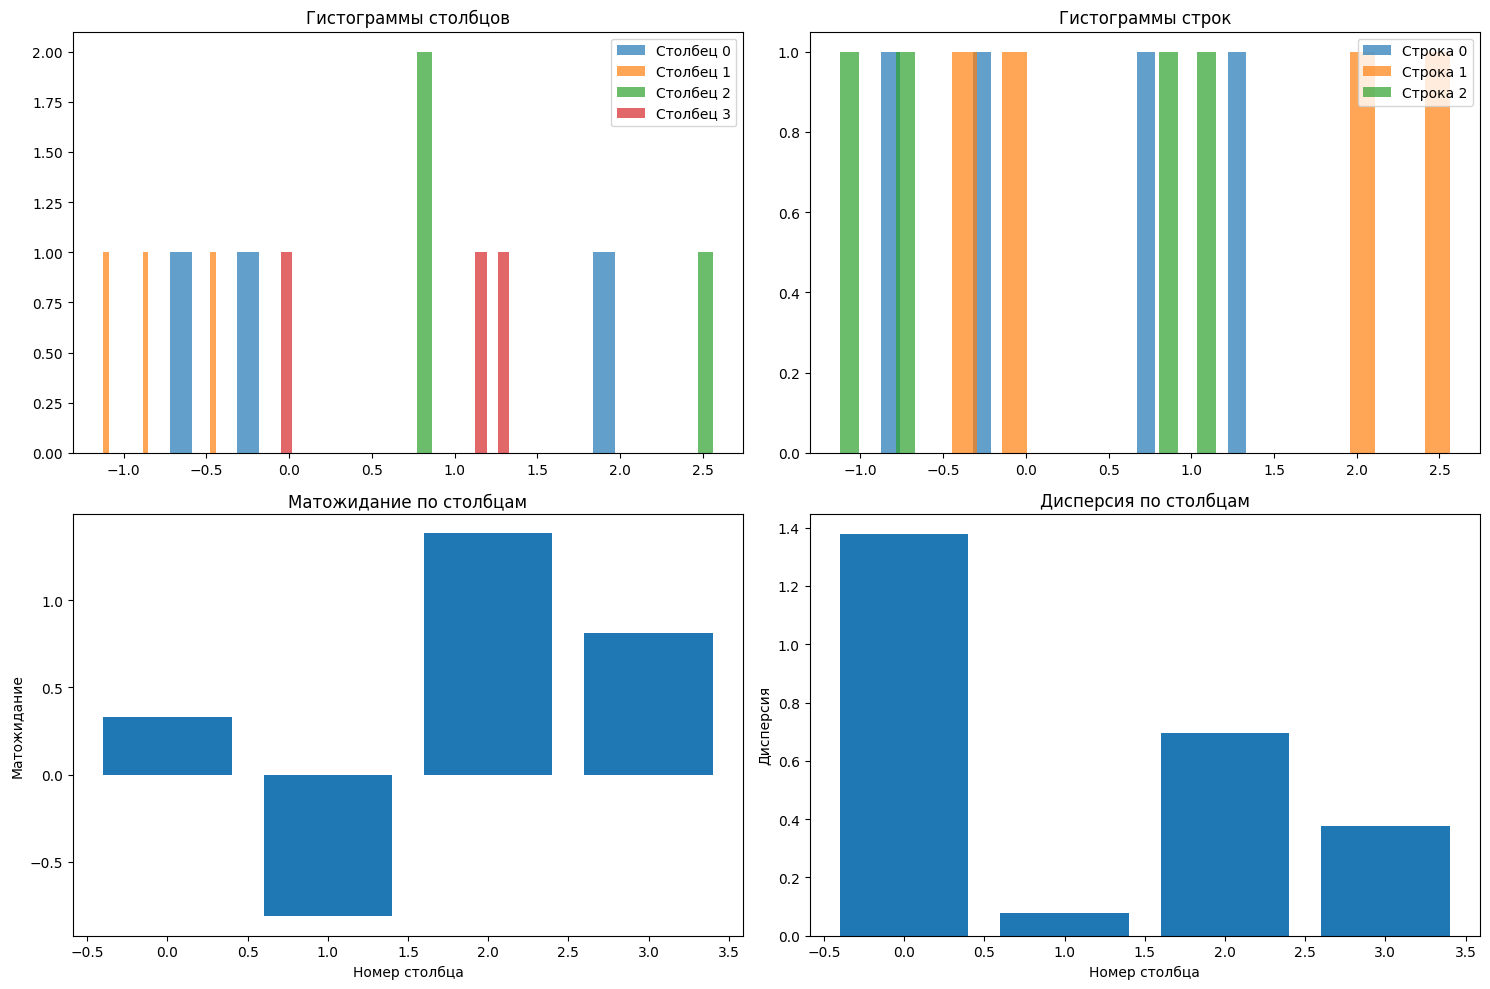

In [41]:
import matplotlib.pyplot as plt
def analyze_matrix(m, n, mean=0, std=1):

    matrix = np.random.normal(mean, std, (m, n))
    print(f"Матрица {m}x{n}:")
    print()

    col_means = np.mean(matrix, axis=0)
    col_vars = np.var(matrix, axis=0)

    print("Статистика по столбцам:")
    for i in range(n):
        print(f"Столбец {i}: матожидание = {col_means[i]:.4f}, дисперсия = {col_vars[i]:.4f}")
    print()
    
    row_means = np.mean(matrix, axis=1)
    row_vars = np.var(matrix, axis=1)
    
    print("Статистика по строкам:")
    for i in range(m):
        print(f"Строка {i}: матожидание = {row_means[i]:.4f}, дисперсия = {row_vars[i]:.4f}")
    print()
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    for i in range(min(n, 5)):
        plt.hist(matrix[:, i], alpha=0.7, label=f'Столбец {i}', bins=20)
    plt.title('Гистограммы столбцов')
    plt.legend()

    plt.subplot(2, 2, 2)
    for i in range(min(m, 5)): 
        plt.hist(matrix[i, :], alpha=0.7, label=f'Строка {i}', bins=20)
    plt.title('Гистограммы строк')
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.bar(range(n), col_means)
    plt.title('Матожидание по столбцам')
    plt.xlabel('Номер столбца')
    plt.ylabel('Матожидание')
    
    plt.subplot(2, 2, 4)
    plt.bar(range(n), col_vars)
    plt.title('Дисперсия по столбцам')
    plt.xlabel('Номер столбца')
    plt.ylabel('Дисперсия')
    
    plt.tight_layout()
    plt.show()
    
    return matrix

def tests():
    mat1 = analyze_matrix(3, 4)
tests()


<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [46]:
def chess(m, n, a, b):
    matrix = np.zeros((m, n), dtype=type(a))
    
    for i in range(m):
        for j in range(n):
            if (i + j) % 2 == 0:
                matrix[i, j] = a
            else:
                matrix[i, j] = b
                
    return matrix

def tests():

    result1 = chess(2, 2, 0, 1)
    expected1 = np.array([[0, 1], [1, 0]])
    print("Результат:")
    print(result1)
    print("Ожидалось:")
    print(expected1)
    print()

    result2 = chess(3, 3, 'A', 'B')
    expected2 = np.array([['A', 'B', 'A'], ['B', 'A', 'B'], ['A', 'B', 'A']])
    print("Результат:")
    print(result2)
    print("Ожидалось:")
    print(expected2)
tests()

Результат:
[[0 1]
 [1 0]]
Ожидалось:
[[0 1]
 [1 0]]

Результат:
[['A' 'B' 'A']
 ['B' 'A' 'B']
 ['A' 'B' 'A']]
Ожидалось:
[['A' 'B' 'A']
 ['B' 'A' 'B']
 ['A' 'B' 'A']]


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

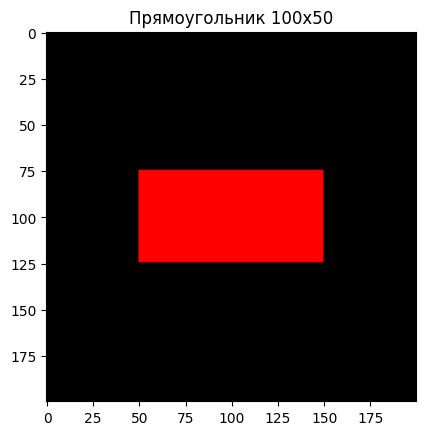

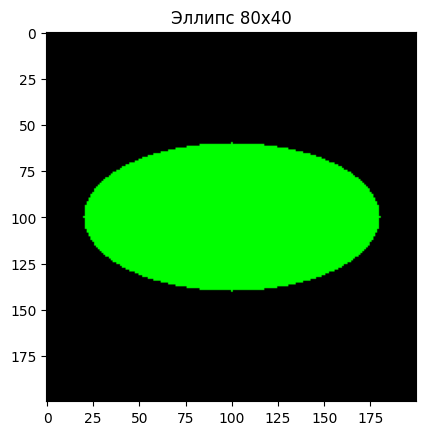

In [49]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    image = np.zeros((m, n, 3), dtype=np.uint8)
    image[:, :] = background_color
    
    x_start = (n - a) // 2
    y_start = (m - b) // 2
    x_end = x_start + a
    y_end = y_start + b
    
    x_start = max(0, x_start)
    y_start = max(0, y_start)
    x_end = min(n, x_end)
    y_end = min(m, y_end)
    
    image[y_start:y_end, x_start:x_end] = rectangle_color
    
    return image

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    image = np.zeros((m, n, 3), dtype=np.uint8)
    image[:, :] = background_color
    
    x0, y0 = n // 2, m // 2
    
    for y in range(m):
        for x in range(n):
            if ((x - x0) ** 2) / (a ** 2) + ((y - y0) ** 2) / (b ** 2) <= 1:
                image[y, x] = ellipse_color
    
    return image

def tests():
    rect1 = draw_rectangle(100, 50, 200, 200, (255, 0, 0), (0, 0, 0))
    plt.imshow(rect1)
    plt.title("Прямоугольник 100x50")
    plt.show()

    ellipse1 = draw_ellipse(80, 40, 200, 200, (0, 255, 0), (0, 0, 0))
    plt.imshow(ellipse1)
    plt.title("Эллипс 80x40")
    plt.show()
tests()

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [51]:
time_series = np.random.rand(50)

mean_value, var_value, deviation = np.mean(time_series), np.var(time_series), np.std(time_series)
print(f"Среднее: {mean_value:.4f}\nДисперсия: {var_value:.4f}\nСтандартное отклонение: {deviation:.4f}")

is_max = (time_series[1:-1] > time_series[:-2]) & (time_series[1:-1] > time_series[2:])
is_min = (time_series[1:-1] < time_series[:-2]) & (time_series[1:-1] < time_series[2:])

local_max = np.where(is_max)[0] + 1
local_min = np.where(is_min)[0] + 1

print(f"Локальные максимумы (значения): {time_series[local_max]}")
print(f"Локальные минимумы (значения): {time_series[local_min]}")

p = 10
moving_average = np.convolve(time_series, np.ones(p)/p, 'valid')
print(f"\nСкользящее среднее (окно={p}): {moving_average}")

Среднее: 0.4857
Дисперсия: 0.0682
Стандартное отклонение: 0.2612
Локальные максимумы (значения): [0.77712098 0.71002696 0.90866592 0.81146072 0.45400256 0.64285697
 0.91773526 0.86438975 0.98066805 0.8603102  0.58484493 0.63674021
 0.50507665 0.69820672 0.76962951]
Локальные минимумы (значения): [0.45641467 0.05152295 0.08633552 0.36946473 0.06440746 0.02913645
 0.59459682 0.29426936 0.29548159 0.31566302 0.19830722 0.09164448
 0.08997118 0.21911661 0.52165352]

Скользящее среднее (окно=10): [0.56591186 0.53429569 0.50198384 0.45324445 0.41404373 0.38861206
 0.41042393 0.42043884 0.33248589 0.33422154 0.34484899 0.3673622
 0.40840092 0.41184664 0.50347269 0.50463903 0.4699015  0.5132014
 0.59631877 0.66888854 0.63651437 0.6186858  0.56381313 0.59287069
 0.51463461 0.5300775  0.56420336 0.5149007  0.45422522 0.41964567
 0.41075397 0.38969449 0.3671253  0.34983139 0.39982134 0.35955275
 0.35124929 0.41904779 0.4458576  0.45734556 0.47069558]


<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [ ]:
def one_hot_encoding(labels):

    labels = np.array(labels)
    n_classes = np.max(labels) + 1
    n_samples = len(labels)
    
    one_hot = np.zeros((n_samples, n_classes))

    one_hot[np.arange(n_samples), labels] = 1
    
    return one_hot

labels1 = [0, 2, 3, 0]
result1 = one_hot_encoding(labels1)
print(result1)


[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
